<a href="https://colab.research.google.com/github/raphateixeira/TCC-Diego/blob/main/PyGad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Algoritmo Genético



#Bibliotecas e módulos

In [ ]:
!pip install pygad
!pip install control

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 KB 4.9 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.8/432.8 KB 13.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pygad
import control as ct
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import animation, rc
from control.matlab import *
from control import matlab
from mpl_toolkits.mplot3d import axes3d
from pylab import *
from IPython.display import HTML
from control import place
from scipy import integrate


plt.rcParams['figure.figsize'] = [8, 8]
plt.rcParams.update({'font.size': 18})

#Função de Transferência


      1
-------------
s^3 + s^2 + s



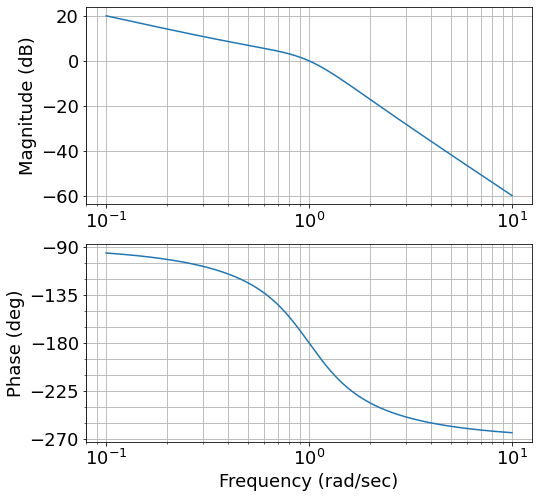

In [ ]:
# Função de transferência
dt = 0.1
s = ct.tf('s')
num = [1]
den = [1,1,1,0]
G = ct.tf(num,den)

bode (G)
print(G)
plt.show()

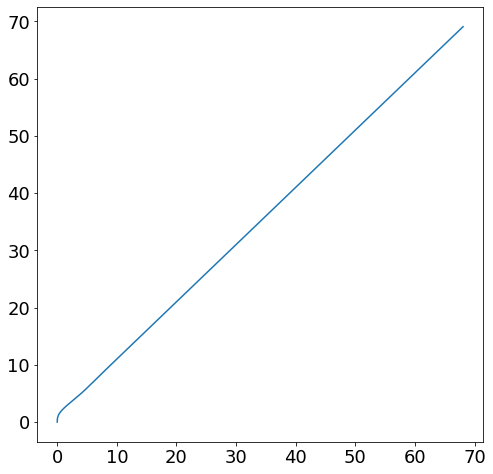

In [ ]:
# Entrada ao degrau
def Step(system):
    plt.figure()
    yout, T = ct.step_response(system)
    plt.plot(T, yout)

Step(G)

#Função Custo

In [ ]:
def PID(parms):
    global G, dt
    s = ct.tf('s')

    Kp = parms[0]
    Ti = parms[1]
    Td = parms[2]
    K = Kp*(1 + 1/(Ti*s) + Td*s/(0.001*s + 1))

    T0 = 0
    N = 600
    t = np.arange(T0,N*dt, dt)

    c = ct.series(K, G)
    Hy = ct.feedback(c, 1)

    t1, yout = ct.step_response(Hy, t)
    uout, t2, xout = lsim(K, U=1-yout, T=t)

    Q = 1
    R = 0.001

    J = dt*sum(Q*(1-yout[:])**2 + R*uout[:]**2)

    # # Plot saída
    # plt.plot(t,yout)
    # plt.title("Indivíduos")
    # plt.grid()
    # plt.show()
    
    return J, t, yout, uout, K

In [ ]:
def fitness_func(solution, solution_idx):
    J, t,  yout, uout, K= PID(solution)
    return -J

In [ ]:
def callback_gen(ga_instance):
  print("Generation: ", ga_instance.generations_completed)
  print("Fitness of the best solution: ", ga_instance.best_solution()[1])
  print(ga_instance.population)

In [ ]:
last_fitness = 0
def on_generation(ga_instance):
    global last_fitness
    print("Generation = {generation}".format(generation=ga_instance.generations_completed))
    print("Fitness    = {fitness}".format(fitness=ga_instance.best_solution(pop_fitness=ga_instance.last_generation_fitness)[1]))
    print("Change     = {change}".format(change=ga_instance.best_solution(pop_fitness=ga_instance.last_generation_fitness)[1] - last_fitness))
    last_fitness = ga_instance.best_solution(pop_fitness=ga_instance.last_generation_fitness)[1]

#AG - Algorítimo Genético

In [ ]:
#  Configuração dos Parâmetros do AG
fitness_function = fitness_func
# Definição da população e dos indivíduos
num_generations = 25
num_parents_mating = 2
num_pop = 25
num_genes = 3

init_range_low = 0.1
init_range_high = 10
# Elitismo
parent_selection_type = "sss"
keep_parents = 1
# Cruzamento
crossover_type = "two_points"
# Mutação
mutation_type = "random"
mutation_percent_genes = 0.01
mutation_num_genes = 1

In [ ]:
ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       fitness_func=fitness_function,
                       sol_per_pop=num_pop,
                       num_genes=num_genes,
                       init_range_low=init_range_low,
                       init_range_high=init_range_high,
                       parent_selection_type=parent_selection_type,
                       keep_parents=keep_parents,
                       crossover_type=crossover_type,
                       mutation_type=mutation_type,
                       mutation_percent_genes=mutation_percent_genes,
                       callback_generation=callback_gen,
                       save_best_solutions=True,
                       save_solutions=True,
                       mutation_num_genes=mutation_num_genes,
                       allow_duplicate_genes=False,
                       stop_criteria="saturate_10",
                       on_generation=on_generation)

/usr/local/lib/python3.8/dist-packages/pygad/pygad.py:764: UserWarning: Starting from PyGAD 2.6.0, the callback_generation parameter is deprecated and will be removed in a later release of PyGAD. Please use the on_generation parameter instead.
  if not self.suppress_warnings: warnings.warn("Starting from PyGAD 2.6.0, the callback_generation parameter is deprecated and will be removed in a later release of PyGAD. Please use the on_generation parameter instead.")
/usr/local/lib/python3.8/dist-packages/pygad/pygad.py:820: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  if not self.suppress_warnings: warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/usr/local/lib/python3.8/dist-packages/pygad/pygad.py:828: UserWarning: Use the 'save_solutions' parameter w

In [ ]:
ga_instance.run()

/usr/local/lib/python3.8/dist-packages/control/timeresp.py:935: UserWarning: return_x specified for a transfer function system. Internal conversion to state space used; results may meaningless.
  warnings.warn(


Generation:  1
Fitness of the best solution:  -180.97871163439666
[[2.07459768 7.03652983 1.23170834]
 [3.16142278 7.03652983 1.28872698]
 [2.07459768 2.85730182 1.04453088]
 [2.07459768 1.14480045 1.23170834]
 [3.16142278 7.03652983 1.82949451]
 [2.75005406 1.99888046 1.23170834]
 [3.56145269 1.99888046 1.23170834]
 [2.42771972 1.99888046 1.23170834]
 [3.65284509 1.99888046 1.23170834]
 [3.16142278 7.24116293 1.23170834]
 [1.47704299 1.99888046 1.04453088]
 [3.92254696 7.03652983 1.23170834]
 [3.28736782 1.99888046 1.23170834]
 [2.07459768 1.99888046 1.40894434]
 [1.29520081 1.99888046 1.04453088]
 [2.07459768 1.63895422 1.23170834]
 [1.28131808 1.99888046 1.04453088]
 [2.07459768 6.06141902 1.04453088]
 [2.57943595 1.99888046 1.04453088]
 [3.16142278 7.03652983 1.82118523]
 [2.69241258 1.99888046 1.23170834]
 [2.07459768 6.06799966 1.04453088]
 [3.56722758 7.03652983 1.04453088]
 [2.01033825 1.99888046 1.23170834]
 [3.16142278 6.5479837  1.04453088]]
Generation:  2
Fitness of the bes

#Gráficos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: ignored

In [ ]:
filename = '/content/drive/MyDrive/Colab Notebooks/dados ag/teste_dados_ag/genetic'
ga_instance.save(filename=filename)
loaded_ga_instance = pygad.load(filename=filename)

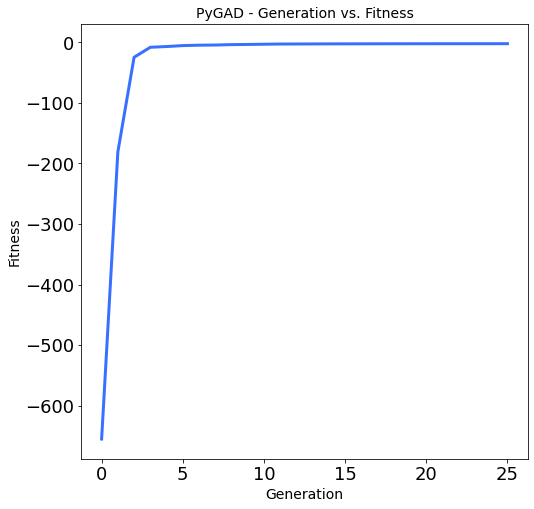

Melhor Solução: [ 0.46 14.17  0.03]
Fitness: 2.26
Index of the best solution : 6
Best fitness value reached after 25 generations.


In [ ]:
ga_instance.plot_fitness()
ga_instance.pop_fitness=True
solution, solution_fitness, solution_idx = ga_instance.best_solution(ga_instance.last_generation_fitness)
print(f"Melhor Solução: {np.round(solution,2)}")
print(f"Fitness: {np.round(-solution_fitness,2)}")
print("Index of the best solution : {solution_idx}".format(solution_idx=solution_idx))
if ga_instance.best_solution_generation != -1:
    print("Best fitness value reached after {best_solution_generation} generations.".format(
        best_solution_generation=ga_instance.best_solution_generation))


/usr/local/lib/python3.8/dist-packages/control/timeresp.py:935: UserWarning: return_x specified for a transfer function system. Internal conversion to state space used; results may meaningless.
  warnings.warn(


Text(0.5, 1.0, 'Control signal')

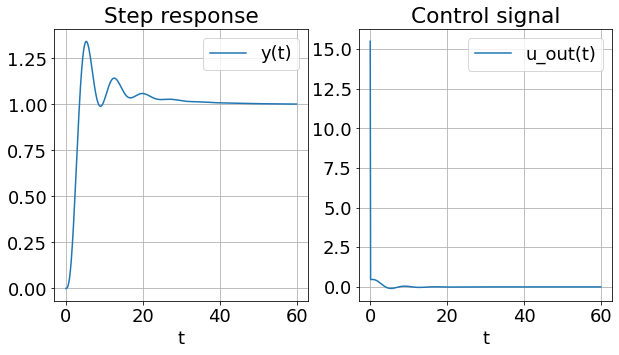

In [ ]:
J,t,y,u,K = PID(solution)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.plot(t, y, label='y(t)')
ax2.plot(t, u, label='u_out(t)')
ax1.grid()
ax2.grid()
ax1.legend()
ax2.legend()  
ax1.set_xlabel('t')
ax2.set_xlabel('t')
ax1.set_title('Step response')
ax2.set_title('Control signal')

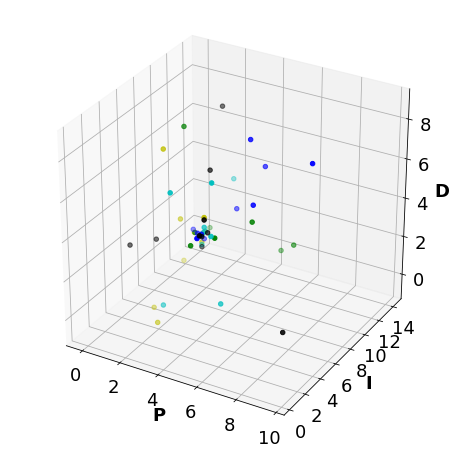

In [ ]:
from mpl_toolkits.mplot3d import axes3d
plt.figure()
k = ga_instance.initial_population
h = ga_instance.population
ax = plt.axes(projection ="3d")

colors = ('y', 'g', 'c', 'b', 'k')
c_list = []
for c in colors:
    c_list.extend([c] * 5)

# Creating plot
sct = ax.scatter(k[:,0], k[:,1], k[:,2], c=c_list)
scct = ax.scatter(h[:,0], h[:,1], h[:,2], c=c_list)

ax.set_xlabel('P', fontweight ='bold')
ax.set_ylabel('I', fontweight ='bold')
ax.set_zlabel('D', fontweight ='bold')

plt.show()

# Rotate the axes and update
# for angle in range(0, 360*4 + 1):
#     # Normalize the angle to the range [-180, 180] for display
#     angle_norm = (angle + 180) % 360 - 180

#     # Cycle through a full rotation of elevation, then azimuth, roll, and all
#     elev = azim = roll = 0
#     if angle <= 360:
#         elev = angle_norm
#     elif angle <= 360*2:
#         azim = angle_norm
#     elif angle <= 360*3:
#         roll = angle_norm
#     else:
#         elev = azim = roll = angle_norm

#     # Update the axis view and title
#     ax.view_init(elev, azim)
#     plt.title("Primeira e última Geração")

#     plt.draw()

#Controlador baseado em otimização
**Controle ótimo:** operação de um sistema dinâmico a um custo mínimo.
**O problema LQR:** Dinâmica do sistema descrita por um conjunto de equações diferênciais lineares com o Custo descrito por uma <font color=yellow>função quadrática.
>A solução é fornecida pelo regulador linear-quadrático (LQR), <font color=yellow>um controlador realimentado. 

>O LQR é uma parte importante da solução para o problema LQG (linear-quadrártico gaussiano).

**Sistemas MIMO:** difícil especificar um overshoot. Os pólos são, do ponto de vista da engenharia, o resultado da raiz do determinante de uma matriz, e possuem uma relação obscura com a resposta temporal. (Usar LQR para sistemas MIMO).

Muitos problemas de controle podem ser expressos como a minimização do "**desvio**" das variáveis controladas, **y**, de seus set-points, **r**.

O significado do desvio pode ser formalizado como, por exemplo, $(y-r)^2$. Desta forma, elevando ao quadrado, penaliza-se tanto os desvios poditivos quanto os negativos.

$e^2 = (y-r)^2$

Inicialmente $r = 0$ será assumido, pois denota qualquer ponto de equilíbrio constante em um modelo linearizado.

$e^2 = y^2 = (Cx)^2$

A função custo é uma função que queremos minimizar, o objetivo é encontrar um compensador que minimize a função J, ou seja, obtenha o menor valor possível.

Para o caso do erro $e^2$, queremos minimizar a função:

$J_c = \int_{0}^{\infty} e^2 \,dt$

$J_d=\sum_{k=0}^{\infty} e(k)^2 \,dt$


Quando falamos em matrizes a função custo assume a forma:

Função custo contínua: $J_c = \int_{0}^{\infty} (Cx)^2 \,dt$

$J_c = \int_{0}^{\infty} ((Cx)^T(Cx)) \,dt = \int_{0}^{\infty} (x^TC^TCx)) \,dt$$

$J_c = \int_{0}^{\infty} (x^TQx) \,dt$

Função custo discreta: $J_d = \sum_{k=0}^{\infty} (C_kx(k))^2$

$J_d = \sum_{k=0}^{\infty} ((C_kx(k))^T(C_kx(k)))^2 = \sum_{k=0}^{\infty} (x(k)^TC_k^TC_kx(k))$$

$J_d = \sum_{k=0}^{\infty} (x(k)^TQ_kx(k))$

Função custo incluíndo agora os desvios na entrada:

$J_c = \int_{0}^{\infty} (x^TQx+u^TRu) \,dt$

Os sinais mudam com o tempo, o objetivo do controle deve ser orientado para minimizar  o "desvio acumulado" tanto dos estados **x** quanto da entrada **u**.



#Modelo linear:
$x=Ax+Bu$,  com $(A, \ B)$ estabilizavel.

##Funcão de custo quadratico:

$\int_{0}^{\infty} [x^T(t)Qx(t) +u^T(t)Ru(t)] \,dt$


$Q=QT≥0,R=RT>0$, com $ (A, \ Q^{1/2}) $ observavel.


In [ ]:
from scipy.signal import tf2ss
import scipy.signal as signal

In [ ]:
A, B, C, D = tf2ss(num, den)

# A = matrix([[0,0,1], [0,-2,-1], [0,0,0]])
# B = matrix([[0,0,1]]).reshape(3,1)
# C = matrix([[0,0,1]])
# D = 0*eye(1)

system = ct.ss(A,B,C,D)
sys = ct.tf(system)

print('system: ',sys)
print('A:\n', A)
print('B:\n', B)
print('C:\n', C)
print('D:\n', D)

system:  
2.665e-15 s^2 + 1.443e-15 s + 1
-------------------------------
         s^3 + s^2 + s

A:
 [[-1. -1. -0.]
 [ 1.  0.  0.]
 [ 0.  1.  0.]]
B:
 [[1.]
 [0.]
 [0.]]
C:
 [[0. 0. 1.]]
D:
 [[0.]]


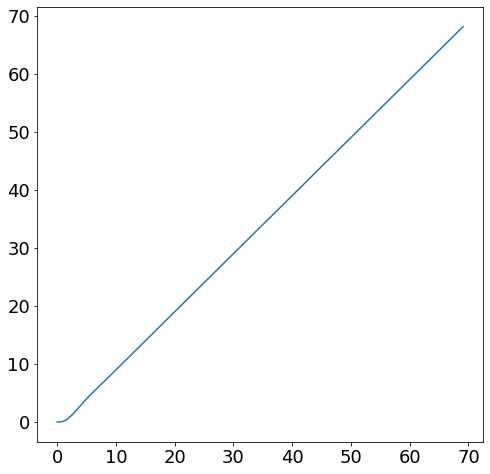

In [ ]:
# Entrada ao degrau
def Step(sys):
    plt.figure()
    yout, T = ct.step_response(sys)
    plt.plot(yout, T)

Step(system)

In [ ]:
def LQR(indiv):

  global A, B, C, D, dt

  T0 = 0
  N = 600
  t = np.arange(T0,N*dt, dt)

  Q = matrix([[indiv[0],0,0],
       [0,indiv[1],0],
       [0,0,indiv[2]]])
  
  R = indiv[3]

  K, S, E = ct.lqr(A, B, Q, R)

  Ac = (A-B@K)

  sys = ct.ss(Ac,B@K@matrix([[1],[0],[0]]),C,D)

  y,t,xout = lsim(sys,dt,t)

  J = dt*sum(np.dot(np.dot(y.T,y),Q)+np.dot(np.dot(Ac.T,Ac),R))

  # plt.plot(t,y)
  # plt.grid()
  # plt.show()

  return J, K, y, t, xout

In [ ]:
def f_func(solution, solution_idx):
    J, K, y, t, xout = LQR(solution)
    return -J

In [ ]:
def callback_gen(ga_instance):
  print("Generation: ", ga_instance.generations_completed)
  print("Fitness of the best solution: ", ga_instance.best_solution()[1])
  print(ga_instance.population)

In [ ]:
last_fitness = 0
def on_generation(ga_instance):
    global last_fitness
    print("Generation = {generation}".format(generation=ga_instance.generations_completed))
    print("Fitness    = {fitness}".format(fitness=ga_instance.best_solution(pop_fitness=ga_instance.last_generation_fitness)[1]))
    print("Change     = {change}".format(change=ga_instance.best_solution(pop_fitness=ga_instance.last_generation_fitness)[1] - last_fitness))
    last_fitness = ga_instance.best_solution(pop_fitness=ga_instance.last_generation_fitness)[1]

In [ ]:
#  Configuração dos Parâmetros do AG
fitness_function = f_func
# Definição da população e dos indivíduos
num_generations = 10
num_parents_mating = 2
num_pop = 5
num_genes = 4

init_range_low = 0.1
init_range_high = 10
# Elitismo
parent_selection_type = "sss"
keep_parents = 1
# Cruzamento
crossover_type = "two_points"
# Mutação
mutation_type = "random"
mutation_percent_genes = 0.01
mutation_num_genes = 1

In [ ]:
ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       fitness_func=fitness_function,
                       sol_per_pop=num_pop,
                       num_genes=num_genes,
                       init_range_low=init_range_low,
                       init_range_high=init_range_high,
                       parent_selection_type=parent_selection_type,
                       keep_parents=keep_parents,
                       crossover_type=crossover_type,
                       mutation_type=mutation_type,
                       mutation_percent_genes=mutation_percent_genes,
                       save_best_solutions=True,
                       save_solutions=True,
                       mutation_num_genes=mutation_num_genes,
                       allow_duplicate_genes=False,
                       stop_criteria="saturate_10",
                       on_generation=on_generation,
                       callback_generation=callback_gen)

In [ ]:
ga_instance.run()

Generation:  1
Fitness of the best solution:  -13.315317431015036
[[7.91717774 1.65970891 7.52509274 0.23326649]
 [8.32234891 5.10504725 2.61945967 0.23326649]
 [7.91717774 1.65970891 2.61945967 9.72650587]
 [8.35795827 1.65970891 2.61945967 9.726719  ]
 [1.96303611 5.10504725 7.52509274 0.23326649]]
Generation:  2
Fitness of the best solution:  -10.674806333045062
[[1.96303611 5.10504725 7.52509274 0.23326649]
 [1.96303611 1.30520908 7.52509274 0.23326649]
 [8.06018692 5.10504725 7.52509274 0.23326649]
 [1.96303611 2.21987709 7.52509274 0.23326649]
 [7.91717774 5.10504725 7.99991901 0.23326649]]


LinAlgError: ignored

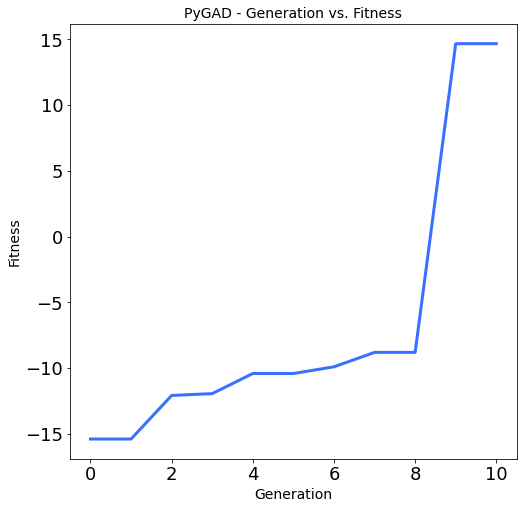

Melhor Solução: [ 1.85 -0.63  5.86 -0.21]
Fitness: -14.68
Index of the best solution : 0
Best fitness value reached after 9 generations.


In [ ]:
ga_instance.plot_fitness()
ga_instance.pop_fitness=True
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f"Melhor Solução: {np.round(solution,2)}")
print(f"Fitness: {np.round(-solution_fitness,2)}")
print("Index of the best solution : {solution_idx}".format(solution_idx=solution_idx))
if ga_instance.best_solution_generation != -1:
    print("Best fitness value reached after {best_solution_generation} generations.".format(
        best_solution_generation=ga_instance.best_solution_generation))


Text(0.5, 1.0, 'Control signal')

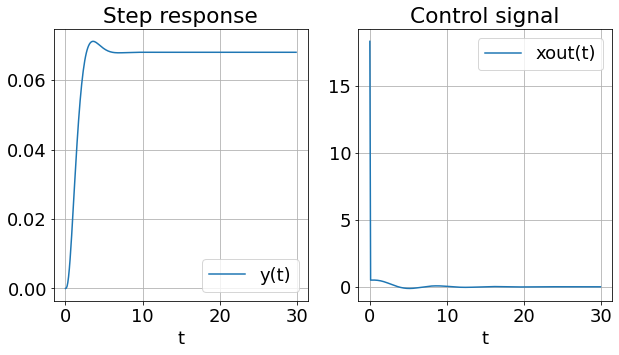

In [ ]:
J, K, y, t, xout = LQR(solution)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.plot(t, y, label='y(t)')
ax2.plot(t, u, label='xout(t)')
ax1.grid()
ax2.grid()
ax1.legend()
ax2.legend()  
ax1.set_xlabel('t')
ax2.set_xlabel('t')
ax1.set_title('Step response')
ax2.set_title('Control signal')